# Credit Scoring Model - 02: Data Quality Assessment

**Objective:** Assess data quality — missing values, data types, anomalies, and outliers.

---

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from eda_utils import load_data, data_quality_report, detect_outliers, impute_missing_values

# Enable inline plotting for Jupyter
%matplotlib inline

sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = load_data('../data/cs-training.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded: 150,000 rows × 11 columns


## 1. Data Quality Report

In [2]:
quality_report = data_quality_report(df)
print('Data Quality Report:')
print('=' * 100)
quality_report

Data Quality Report:


,Column,Data_Type,Missing_Count,Missing_Percentage,Unique_Values,Sample_Values
5,MonthlyIncome,float64,29731,19.820667,13594,"[9120.0, 2600.0, 3042.0]"
10,NumberOfDependents,float64,3924,2.616000,13,"[2.0, 1.0, 0.0]"
0,SeriousDlqin2yrs,int64,0,0.000000,2,"[1, 0, 0]"
2,age,int64,0,0.000000,86,"[45, 40, 38]"
1,RevolvingUtilizationOfUnsecuredLines,float64,0,0.000000,125728,"[0.766126609, 0.957151019, 0.65818014]"
4,DebtRatio,float64,0,0.000000,114194,"[0.802982129, 0.121876201, 0.085113375]"
3,NumberOfTime30-59DaysPastDueNotWorse,int64,0,0.000000,16,"[2, 0, 1]"
6,NumberOfOpenCreditLinesAndLoans,int64,0,0.000000,58,"[13, 4, 2]"
7,NumberOfTimes90DaysLate,int64,0,0.000000,19,"[0, 0, 1]"
8,NumberRealEstateLoansOrLines,int64,0,0.000000,28,"[6, 0, 0]"


## 2. Missing Values Visualization

✓ Figure saved: ../outputs/02_missing_values.png


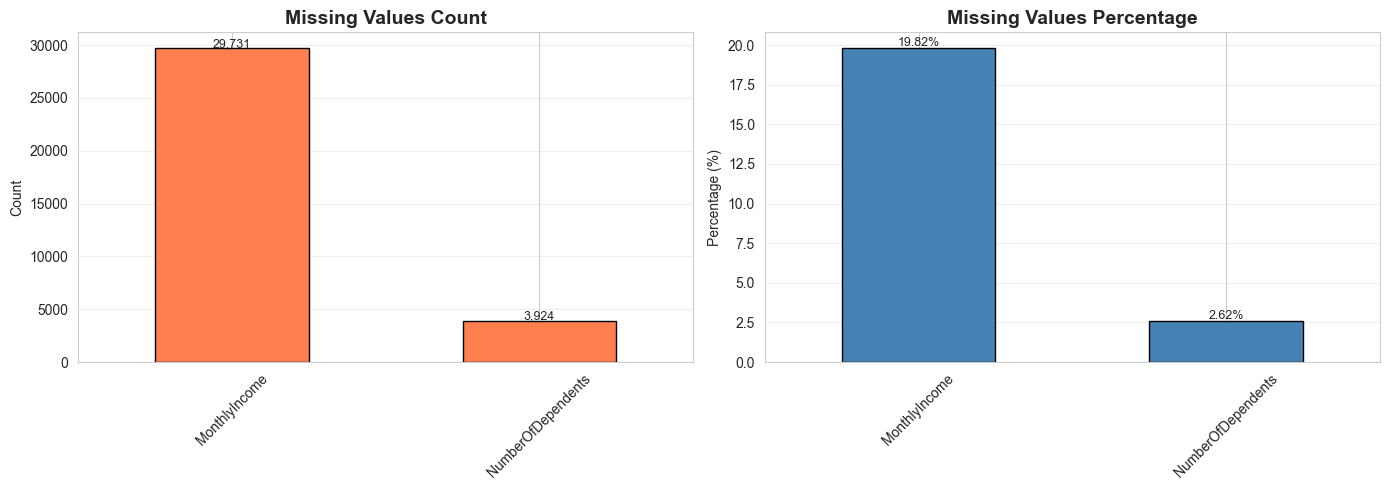


Missing Value Details:
  MonthlyIncome                                   29,731 (19.82%)
  NumberOfDependents                               3,924 (2.62%)


In [3]:
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Count
    missing_data.plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
    axes[0].set_title('Missing Values Count', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(missing_data.values):
        axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

    # Percentage
    missing_pct = (missing_data / len(df) * 100)
    missing_pct.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
    axes[1].set_title('Missing Values Percentage', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Percentage (%)')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(missing_pct.values):
        axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=9)

    plt.tight_layout()
    fig.savefig(f'{OUTPUT_DIR}/02_missing_values.png', dpi=150, bbox_inches='tight')
    print(f'✓ Figure saved: {OUTPUT_DIR}/02_missing_values.png')
    plt.show()
    print('\nMissing Value Details:')
    for col, count in missing_data.items():
        pct = count / len(df) * 100
        print(f'  {col:<45} {count:>8,} ({pct:.2f}%)')
else:
    print('✓ No missing values found!')

## 3. Outlier Detection

In [4]:
numerical_features = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents'
]

print('Outlier Detection Summary (IQR Method)')
print('=' * 80)

outlier_summary = []
for feature in numerical_features:
    outliers = detect_outliers(df, feature, method='iqr')
    outlier_count = outliers.sum()
    outlier_pct = (outlier_count / len(df)) * 100
    outlier_summary.append({
        'Feature': feature,
        'Outlier_Count': outlier_count,
        'Outlier_Percentage': round(outlier_pct, 4)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Percentage', ascending=False)
outlier_df

Outlier Detection Summary (IQR Method)


,Feature,Outlier_Count,Outlier_Percentage
3,DebtRatio,31311,20.8740
2,NumberOfTime30-59DaysPastDueNotWorse,23982,15.9880
9,NumberOfDependents,13336,8.8907
6,NumberOfTimes90DaysLate,8338,5.5587
8,NumberOfTime60-89DaysPastDueNotWorse,7604,5.0693
4,MonthlyIncome,4879,3.2527
5,NumberOfOpenCreditLinesAndLoans,3980,2.6533
7,NumberRealEstateLoansOrLines,793,0.5287
0,RevolvingUtilizationOfUnsecuredLines,763,0.5087
1,age,46,0.0307


✓ Figure saved: ../outputs/02_outlier_summary.png


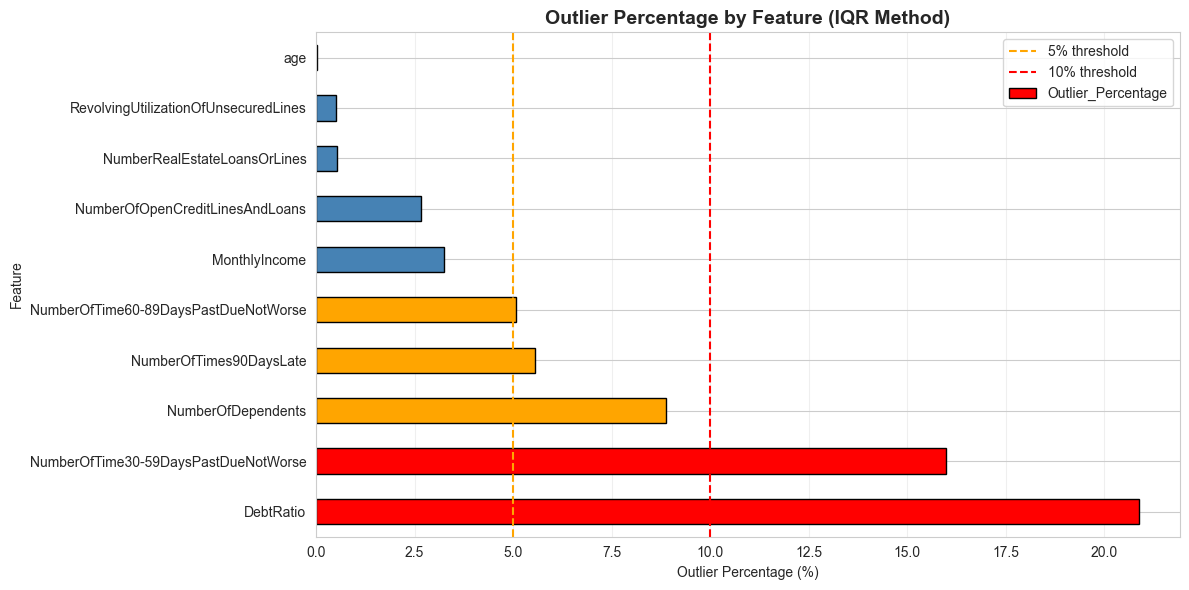


⚠️  Recommendation: Investigate outliers before model training.
  - Winsorization (capping at percentiles)
  - Log transformation for skewed distributions
  - Separate treatment for extreme values


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['red' if x > 10 else 'orange' if x > 5 else 'steelblue'
          for x in outlier_df['Outlier_Percentage']]
outlier_df.set_index('Feature')['Outlier_Percentage'].plot(
    kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Outlier Percentage by Feature (IQR Method)', fontsize=14, fontweight='bold')
ax.set_xlabel('Outlier Percentage (%)')
ax.axvline(x=5, color='orange', linestyle='--', label='5% threshold')
ax.axvline(x=10, color='red', linestyle='--', label='10% threshold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/02_outlier_summary.png', dpi=150, bbox_inches='tight')
print(f'✓ Figure saved: {OUTPUT_DIR}/02_outlier_summary.png')
plt.show()

print('\n⚠️  Recommendation: Investigate outliers before model training.')
print('  - Winsorization (capping at percentiles)')
print('  - Log transformation for skewed distributions')
print('  - Separate treatment for extreme values')

## 4. Data Type Validation

In [6]:
print('Data Type Summary:')
print('=' * 60)
dtype_summary = df.dtypes.reset_index()
dtype_summary.columns = ['Column', 'Data Type']
for _, row in dtype_summary.iterrows():
    print(f'  {row["Column"]:<45} {row["Data Type"]}')

Data Type Summary:
  SeriousDlqin2yrs                              int64
  RevolvingUtilizationOfUnsecuredLines          float64
  age                                           int64
  NumberOfTime30-59DaysPastDueNotWorse          int64
  DebtRatio                                     float64
  MonthlyIncome                                 float64
  NumberOfOpenCreditLinesAndLoans               int64
  NumberOfTimes90DaysLate                       int64
  NumberRealEstateLoansOrLines                  int64
  NumberOfTime60-89DaysPastDueNotWorse          int64
  NumberOfDependents                            float64


## 5. Missing Value Imputation

We'll use **column-specific imputation** methods based on data distribution:
- **Median** for skewed features (e.g., `MonthlyIncome`)
- **Mode** for discrete/categorical features (e.g., `NumberOfDependents`)
- **Mean** for normally distributed features

In [7]:
# Check missing values before imputation
print('Missing Values BEFORE Imputation:')
print('=' * 80)
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)
if len(missing_before) > 0:
    for col, count in missing_before.items():
        pct = count / len(df) * 100
        print(f'  {col:<45} {count:>8,} ({pct:.2f}%)')
else:
    print('  No missing values found!')

# Define column-specific imputation methods
# - MonthlyIncome: use median (typically skewed)
# - NumberOfDependents: use mode (discrete integer values)
# - Other columns: use mean (default)
column_methods = {
    'MonthlyIncome': 'median',
    'NumberOfDependents': 'mode'
}

# Perform column-specific imputation
df_cleaned = impute_missing_values(df, method='mean', column_methods=column_methods)

# Verify no missing values remain
print('\nMissing Values AFTER Imputation:')
print('=' * 80)
missing_after = df_cleaned.isnull().sum()
missing_after = missing_after[missing_after > 0]
if len(missing_after) > 0:
    print(missing_after)
else:
    print('✓ All missing values have been successfully imputed!')
    print(f'✓ Dataset shape remains: {df_cleaned.shape[0]:,} rows × {df_cleaned.shape[1]} columns')

Missing Values BEFORE Imputation:
  MonthlyIncome                                   29,731 (19.82%)
  NumberOfDependents                               3,924 (2.62%)

MISSING VALUE IMPUTATION SUMMARY
  MonthlyIncome                                 Missing: 29,731  →  median →  5400.0000
  NumberOfDependents                            Missing:  3,924  →    mode →     0.0000
✓ Total columns imputed: 2
✓ Total missing values filled: 33,655

Missing Values AFTER Imputation:
✓ All missing values have been successfully imputed!
✓ Dataset shape remains: 150,000 rows × 11 columns


## 6. Save Cleaned Data

Save the cleaned dataset for use in subsequent analysis notebooks.

In [8]:
# Save cleaned data
cleaned_data_path = '../data/cs-training-cleaned.csv'
df_cleaned.to_csv(cleaned_data_path, index=False)

print('\n' + '=' * 80)
print('DATA CLEANING COMPLETE')
print('=' * 80)
print(f'✓ Cleaned dataset saved to: {cleaned_data_path}')
print(f'✓ Shape: {df_cleaned.shape[0]:,} rows × {df_cleaned.shape[1]} columns')
print(f'✓ Missing values: {df_cleaned.isnull().sum().sum()}')
print(f'✓ Memory usage: {df_cleaned.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print('\n✓ This cleaned dataset will be used in:')
print('  - 03_univariate_analysis.ipynb')
print('  - 04_bivariate_analysis.ipynb')
print('  - 05_multivariate_analysis.ipynb')
print('\n✓ Notebook 02 complete. Figures saved to outputs/')


DATA CLEANING COMPLETE
✓ Cleaned dataset saved to: ../data/cs-training-cleaned.csv
✓ Shape: 150,000 rows × 11 columns
✓ Missing values: 0
✓ Memory usage: 12.59 MB

✓ This cleaned dataset will be used in:
  - 03_univariate_analysis.ipynb
  - 04_bivariate_analysis.ipynb
  - 05_multivariate_analysis.ipynb

✓ Notebook 02 complete. Figures saved to outputs/
